# 1-Bit HHL track simulation toy model 4 particles 6 layers

This Jupyter notebook is compatible with Python 3.13, Qiskit v2.2, Qiskit Aer v0.17, Qiskit runtime version: 0.43 and Qiskit Runtime V2 primitives.
|||
|-|-|
|**Author:** |Alain Chancé|
|**Date:** |September 29, 2025|
|**Version:** |**1.00**|
# LHCb_VeLo_Toy_Model_1-Bit_HHL
An efficient implementation of the 1-Bit HHL track simulation toy model at the LHCb at CERN derived from the following publications:
- [Alain Chancé, A Toy Model For Reconstructing Particle Tracks at LHCb at CERN with Quantum Computing, 30 Oct. 2025, LHCb_VeLo_Toy_Model_1-Bit_HHL.pdf](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/LHCb_VeLo_Toy_Model_1-Bit_HHL.pdf).
- [Xenofon Chiotopoulos, Davide Nicotra, George Scriven, Kurt Driessens, Marcel Merk, Jochen Schütz, Jacco de Vries, Mark H.M. Winands, TrackHHL: The 1-Bit Quantum Filter for particle trajectory reconstruction, 12 Jan 2026, arXiv:2601.07766](https://doi.org/10.48550/arXiv.2601.07766)
- [Xenofon Chiotopoulos, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb](https://indico.cern.ch/event/1338689/contributions/6010017/attachments/2951297/5188722/CHEP_ppt.pdf)
- Xenofon Chiotopoulos, Miriam Lucio Martinez, Davide Nicotra, Jacco A. de Vries, Kurt Driessens, Marcel Merk, and Mark H.M. Winands, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb, EPJ Web of Conferences 337, 01181 (2025), [https://doi.org/10.1051/epjconf/202533701181](https://doi.org/10.1051/epjconf/202533701181).
- [D. Nicotra et al., arXiv:2308.00619v2, 7 Oct 2023, A quantum algorithm for track reconstruction in the LHCb vertex detector](https://arxiv.org/pdf/2308.00619).

## Import libraries

In [1]:
import matplotlib.pyplot as plt

In [2]:
from One_Bit_HHL_Simulation import One_Bit_HHL

Qiskit version: 2.2.3
Qiskit Aer version: 0.17.2
Qiskit runtime version: 0.43.1


## Setup configuration parameters

In [3]:
config = {
    #--------------------
    # Simulation options
    #--------------------
    "dz": 20,                           # layer spacing (mm)
    "layers": 6,                        # Number of layers
    "n_particles": [2, 2],              # Number of particles
    "p_vertices": [(0,0,5), (0,0,10)],  # Primary vertices
    "do_draw": False,                   # Whether to draw the HHL circuit
    "measurement_error": 0.0,           # HIT RESOLUTION (sigma on measurement) (sigma)
    "collision_noise": 0.0,             # MULTIPLE SCATTERING (angular noise proxy)
    "ghost_rate": 1e-2,                 # Ghost (fake) track rate
    "drop_rate": 0.0,                   # Hit drop (inefficiency) rate
    "display_particles": False,         # Whether to display initial particle states
    "display_hits": True,               # Whether to display hits
    "display_ghost_hits": True,         # Whether to display ghost hits
    "display_tracks": True,             # Whether to display events and ghost tracks
    "display_clusters": False,          # Whether to display clusters found by find_tracks()
    "display_false_clusters": True,     # Whether to display clusters rejected by find_tracks()
    "do_plot_tracks": True,             # Whether to plot events and ghost tracks
    "do_solve_scipy": False,            # Whether to solve classically using scipy.sparse.linalg.cg
    "T_classical": None,                # Threshold for discretizing classical solutions
    "T_hhl": None,                      # Threshold for discretizing 1-Bit HHL solutions - None: to be computed
    "do_spectrum": False,               # Whether to analyze the classical solution spectrum
    "do_print_counts": False,           # Whether to print raw measurement counts
    "do_print_outer_segs": False,       # Whether to print segments in modules greater than 3
    "tol": 1e-6,                        # Tolerance for floating point comparison
    #------------------------------------------
    # Files containing token (API key) and CRN
    #------------------------------------------
    "token_file": "Token.txt",          # Token file
    "CRN_file": "CRN.txt",              # CRN file
    #-------------
    # Run options
    #-------------
    "backend_name": "AerSimulator noiseless",          # AerSimulator noiseless or Fake QPU or real IBM cloud backend name
    "job_id": None,                     # job_id of a previously run job
    "run_on_QPU": False,                # Whether to run the quantum circuit on the target hardware
    "nshots": 10000,                    # Number of shots
    'opt_level': 3,                     # Optimization level
    "poll_interval": 5,                 # Poll interval in seconds for job monitor
    "timeout": 600,                     # Time out in seconds for job monitor
    #-------------------------------------
    # eco2AI Tracker options
    # https://github.com/sb-ai-lab/Eco2AI
    #-------------------------------------
    "do_eco2ai": True,                                # Whether to use the eco2AI Tracker
    "project_name": "One_Bit_HHL",                    # Project name
    "experiment_description": "HHL_4_p_6_l_find_tracks", # Experiment description
    "eco2ai_file_name": "HHL_4_p_6_l_find_tracks.csv",   # eco2AI file name
    #---------------------------------------------------------------------------------
    # Ballpark figure (kW) for the power consumption of the IBM cloud backend
    # "The power consumption of a quantum computer is about 15-25kW"
    # https://www.capgemini.com/insights/expert-perspectives/green-quantum-computing/
    #---------------------------------------------------------------------------------
    "power_QPU": 25,                    # Ballpark figure (kW) for the power consumption of the IBM cloud backend
}

## Create an instance of the One_Bit_HHL class from the configuration dictionary

In [4]:
try:
    My_HHL = One_Bit_HHL(**config)
except Exception as e:
   print(f"Error creating 1_Bit_HHL instance: {e}")


Simulation options
layer spacing (mm), dz: 20
layers: 6
n_particles: [2, 2], Total number: 4
primary_vertices: [(0, 0, 5), (0, 0, 10)]
do_draw: False
measurement hit resolution: 0.0
multiple scattering collision noise: 0.0
ghost (fake) track rate: 0.01
hit drop (inefficiency) rate: 0.0
display_particles: False
display_hits: True
display_ghost_hits: True
display_tracks: True
display_clusters: False
display_false_clusters: True
do_plot_tracks: True
do_plot_heat_map: False
do_solve_scipy: False
T_classical: None
T_hhl: None
do_spectrum: False
do_print_counts: False
do_print_outer_segs False
resolution: 25
tol: 1e-06
tol_clusters: 1e-06
tol_intersects: 1e-06

Run options
Backend name: AerSimulator noiseless
Run on QPU: False
Optimization level: 3

eco2AI Tracker options
project_name: One_Bit_HHL
experiment_description: HHL_4_p_6_l_find_tracks
eco2ai_file_name: HHL_4_p_6_l_find_tracks.csv

Ballpark figure (kW) for QPU power consumption: 25

Deleted: HHL_4_p_6_l_find_tracks.csv
eco2AI track

## Setup events


-------------------------------------------------------------
 All 24 true hits created by the function make_noisy_event()
-------------------------------------------------------------

     Hit ID       x         y         z       Theta      Module ID
       0        -2.04     -2.07     20.00    -2.348          1
       1        -4.75     -4.83     40.00    -2.348          2
       2        -7.46     -7.59     60.00    -2.348          3
       3       -10.18    -10.35     80.00    -2.348          4
       4       -12.89    -13.10    100.00    -2.348          5
       5       -15.60    -15.86    120.00    -2.348          6
       6        -2.84     -2.11     20.00    -2.503          1
       7        -6.62     -4.92     40.00    -2.503          2
       8       -10.41     -7.73     60.00    -2.503          3
       9       -14.19    -10.55     80.00    -2.503          4
      10       -17.98    -13.36    100.00    -2.503          5
      11       -21.77    -16.17    120.00    -2.503  

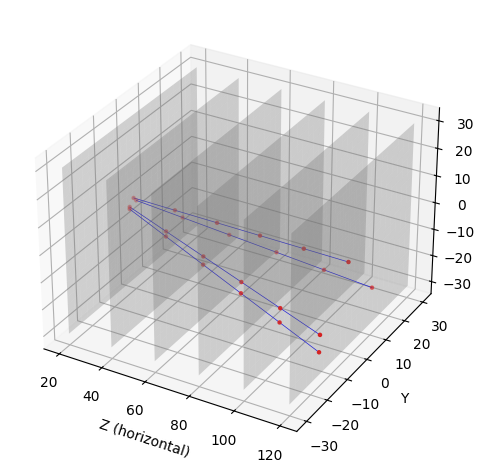


------------------------------------------------
 Polar plot of hits projected onto the XY plane
------------------------------------------------


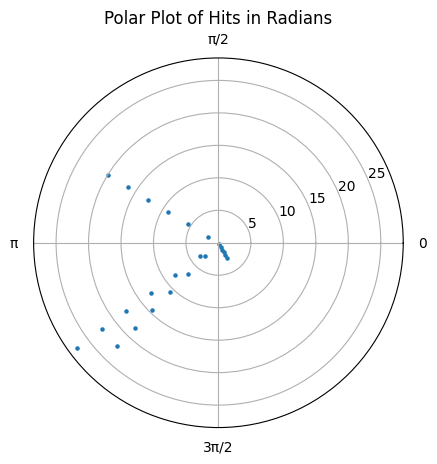


------------------------------------------------------
 ✅ Function setup_events() completed in 0.46 seconds 
------------------------------------------------------


In [5]:
My_HHL.setup_events()

## Run classical and 1-Bit HHL simulations


--------------------------------------------
 ✅ find_tracks() completed in 0.00 seconds 
--------------------------------------------

----------------------------------------
 find_tracks() found 2 primary vertices
----------------------------------------
(0.000, 0.000, 5.000)
(0.000, 0.000, 10.000)

------------------------------
 find_tracks() found 4 tracks
------------------------------

--------------------------------------------------
 All 4 tracks found by the function find_tracks()
--------------------------------------------------

Track ID: 0
     Hit ID       x         y         z       Theta      Module ID
       0        -2.04     -2.07     20.00    -2.348          1
       1        -4.75     -4.83     40.00    -2.348          2
       2        -7.46     -7.59     60.00    -2.348          3
       3       -10.18    -10.35     80.00    -2.348          4
       4       -12.89    -13.10    100.00    -2.348          5
       5       -15.60    -15.86    120.00    -2.348     

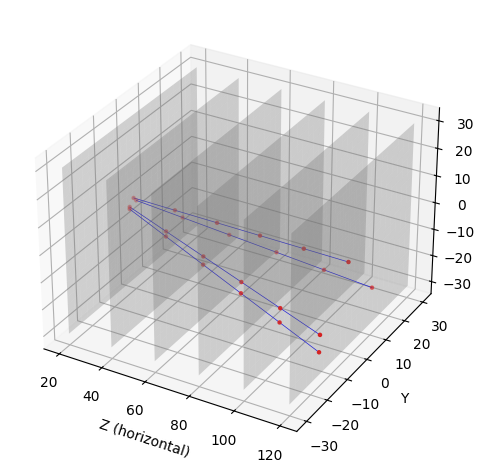


Classical processing - Duration (h): 0.0003 - Power consumption (kWh): 0.0000


In [6]:
My_HHL.run_simulation()

In [7]:
# Display Markdown file from the GitHub repository LHCb_VeLo_Toy_Model_1-Bit_HHL
import requests
from IPython.display import Markdown, display

url = "https://raw.githubusercontent.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/main/README.md"

response = requests.get(url)
response.raise_for_status()  # ensures errors are visible

display(Markdown(response.text))

# LHCb_VeLo_Toy_Model_1-Bit_HHL
An efficient implementation of the 1-Bit HHL track simulation toy model at the LHCb at CERN derived from the following publications:
- [Alain Chancé, A Toy Model For Reconstructing Particle Tracks at LHCb at CERN with Quantum Computing, 30 Oct. 2025, LHCb_VeLo_Toy_Model_1-Bit_HHL.pdf](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/LHCb_VeLo_Toy_Model_1-Bit_HHL.pdf).
- [Xenofon Chiotopoulos, Davide Nicotra, George Scriven, Kurt Driessens, Marcel Merk, Jochen Schütz, Jacco de Vries, Mark H.M. Winands, TrackHHL: The 1-Bit Quantum Filter for particle trajectory reconstruction, 12 Jan 2026, arXiv:2601.07766](https://doi.org/10.48550/arXiv.2601.07766)
- [Xenofon Chiotopoulos, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb](https://indico.cern.ch/event/1338689/contributions/6010017/attachments/2951297/5188722/CHEP_ppt.pdf)
- Xenofon Chiotopoulos, Miriam Lucio Martinez, Davide Nicotra, Jacco A. de Vries, Kurt Driessens, Marcel Merk, and Mark H.M. Winands, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb, EPJ Web of Conferences 337, 01181 (2025), [https://doi.org/10.1051/epjconf/202533701181](https://doi.org/10.1051/epjconf/202533701181).
- [D. Nicotra et al., arXiv:2308.00619v2, 7 Oct 2023, A quantum algorithm for track reconstruction in the LHCb vertex detector](https://arxiv.org/pdf/2308.00619)

# The Large Hadron Collider beauty (LHCb) experiment at CERN
The LHCb Experiment at CERN is a general-purpose detector at the Large Hadron Collider (LHC) and specializes in investigating the slight differences between matter and antimatter by studying a type of particle called the "beauty quark", or "b quark".

It uses a series of subdetectors to detect mainly forward particles – those thrown forwards by the collision in one direction. The first subdetector is mounted close to the collision point, with the others following one behind the other over a length of 20 meters.
The 5600-tonne LHCb detector is made up of a forward spectrometer and planar detectors. It is 21 meters long, 10 meters high and 13 meters wide, and sits 100 meters below ground near the town of Ferney-Voltaire, France. 

As of 2024, more than 1600 members from 98 institutes in 22 countries, including 1100 authors.
Source: https://home.cern/science/experiments/lhcb 

# Particle track reconstruction in the LHCb Vertex Locator (VELO)
In the High Luminosity phase of the Large Hadron Collider (HL-LHC), thousands of particles are produced simultaneously. Particles leave energy hits in detector layers. Hits are reconstructed into particle tracks. Tracks reveal Primary Vertices (collision points). Tracks in the LHCb Vertex Locator (VELO) can be modeled as straight lines intersecting the z-axis because it is the sub-detector closest to the LHCb collision point and it contains a negligible magnetic field.

## Classical sort-by-angle theta particle track reconstruction
In the XY projection, these straight lines pass through the origin. As a result, energy hits are likely to have a constant phase in polar coordinates when projected onto the XY plane (see Section 3, *Search by triplet — Sort by φ*, in [ALGO-10](https://arxiv.org/pdf/2207.03936)).  

We have developed the following functions:
- `plot_hits_polar()`, which displays a plot in Radians of hits projected onto the XY plane. See for example [LHCb_VeLo_Toy_Model_1-Bit_HHL/8_particles/6_layers/fake_fez/Polar_Plot_8_p_6_l_fake_fez.png](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/8_particles/6_layers/fake_fez/Polar_Plot_8_p_6_l_fake_fez.png).
- `cluster_by_last_column()`, which clusters hits by the last-column polar angle `theta` of an array of hits.
- `segment_intersects_z_axis()`, which checks whether a line intersects the z-axis and finds the corresponding primary vertex.  
- `find_tracks()`, which reconstructs tracks from these clusters and finds all primary vertices.

The computational bottleneck in the function `cluster_by_last_column()` is the comparison-based sorting step, for which both classical and bounded-error quantum query complexities are $O(n. \log n)$; quantum algorithms do not reduce the asymptotic number of comparisons required.

Høyer, P.; Neerbek, J.; Shi, Y. (2001). "Quantum complexities of ordered searching, sorting, and element distinctness". 
28th International Colloquium on Automata, Languages, and Programming. Lecture Notes in Computer Science. 
Vol. 2076. pp. 62–73. [arXiv:quant-ph/0102078](https://arxiv.org/abs/quant-ph/0102078). doi:10.1007/3-540-48224-5_29. ISBN 978-3-540-42287-7.

The function `find_tracks()` has successfully reconstructed toy events with several thousands of particles in less than a fraction of a second, as shown in the following Jupyter notebooks:
  - [1024_particles/7_layers/Find_tracks/HHL_1024_particles_7_layers_find_tracks.ipynb](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/1024_particles/7_layers/Find_tracks/HHL_1024_particles_7_layers_find_tracks.ipynb)
  - [2256_particles/8_layers/Find_tracks/HHL_2256_particles_8_layers_find_tracks.ipynb](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/2256_particles/8_layers/Find_tracks/HHL_2256_particles_8_layers_find_tracks.ipynb)
  - [5000_particles/7_layers/Find_tracks/HHL_5000_particles_7_layers_find_tracks.ipynb](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/5000_particles/7_layers/Find_tracks/HHL_5000_particles_7_layers_find_tracks.ipynb)

## Reconstructing tracks by minimizing an Ising-like Hamiltonian using matrix inversion
The Hamiltonian $𝐻(𝑆)$ is parametrized in terms of doublets $𝑆$, these doublets are possible connections between two hits in subsequent detector layers and take a binary value to indicate if they actively contribute to a track, $S_i \in${0, 1}. It includes three terms:

- The angular term $𝐻_{𝑎𝑛𝑔}$ is the most important as it determines if a set of doublets $𝑆_𝑖$ and $𝑆_𝑗$ are aligned within $\varepsilon$.
- $𝐻_{spec}(𝑆)$ makes the spectrum of $A$ positive.
- $𝐻_{gap}(𝑆)$ ensures gap in the solution spectrum.

$$𝐻(𝑆) = 𝐻_{𝑎𝑛𝑔}(𝑆,\varepsilon)+\gamma𝐻_{spec}(𝑆)+\delta𝐻_{gap}(𝑆)$$

$$H_{\text{ang}}(S,\varepsilon) = -\frac{1}{2} \left[ \sum_{abc} f(\theta_{abc}, \varepsilon) S_{ab} S_{bc} \right]$$

$$𝐻_{spec}(𝑆)=\sum_{𝑎𝑏} 𝑆_{𝑎𝑏}^2$$

$$𝐻_{gap}(𝑆)=\sum_{𝑎𝑏} (1−2S_{𝑎𝑏})^2)$$

$$
f(\theta_{abc}, \varepsilon) =
\begin{cases}
1 & \text{if } \cos(\theta_{abc}) \geq 1 - \varepsilon \\
0 & \text{otherwise}
\end{cases}
$$

$$𝐻(𝑆)=−\frac{1}{2} \left[\sum_{abc} f(\theta_{abc}, \varepsilon) S_{ab} S_{bc} + \gamma\sum_{𝑎𝑏} 𝑆_{𝑎𝑏}^2 + \delta\sum_{𝑎𝑏} (1−2S_{𝑎𝑏} )^2\right]$$ 

By relaxing $𝑆_𝑖\inℝ$, we find its minimum by taking the derivative of the quadratic $𝐻$, obtaining a system of linear equations:

$$∇_𝑆 H=−AS+b=0,  AS=b$$

Matrix inversion yields the solution of reconstructed tracks. The resulting vector $𝑆$ of real values is subsequently discretized to obtain an "on"/"off" status by setting a threshold $𝑇$.

## Efficient implementation of the track reconstruction by minimizing an Ising-like Hamiltonian

## Fast construction of the Hamiltonian $H(S)$
The function `construct_segments()` of the class `SimpleHamiltonian` in the module [toy_model/simple_hamiltonian.py](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/toy_model/simple_hamiltonian.py) is enhanced to identify segments with matching values of `theta` during their creation and to append them to the list `segment_in_indices`, along with their corresponding segment IDs in the list `segment_indices`. The function `construct_hamiltonian()` then considers only doublets $S_i$ and $S_j$ of segments in `segment_in_indices`. This modification significantly improves the performance of the preprocessing step.

## Smart error detection and recovery
The function `get_tracks_smart()` of the class `One_Bit_HHL` in the module [One_Bit_HHL_Simulation.py](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/One_Bit_HHL_Simulation.py) performs the following steps:
  - Identifies active segments in the first three layers from both the classical solution and the 1-bit HHL quantum solution.  
  - Reconstructs tracks using only segments that intersect the z-axis; their intersection points define the reconstructed primary vertices.  
  - Adds missed segments intersecting the z-axis and extends active segments to all outer layers.

## Solving the system of linear equations classically
The function `classical_simulation()` of the class `One_Bit_HHL` in the module `One_Bit_HHL_Simulation.py` uses only the first three layers of the toy event created by the function `setup_events()` in the same module.

The system of linear equations $𝐴𝑆=𝑏$ is solved using [scipy.sparse.linalg.cg](https://docs.scipy.org/doc/scipy-1.12.0/reference/generated/scipy.sparse.linalg.cg.html):

```python
sol, _ = sci.sparse.linalg.cg(A, vector_b, atol=0)
```
The discretized solution is obtained by setting a threshold `T_classical` in the list of configuration parameters `param`:
```python
T_classical = param["T_classical"]
disc_sol = (sol > T_classical).astype(int)
```

## Solving the system of linear equations with the 1-Bit HHL algorithm
The Harrow–Hassidim–Lloyd (HHL) algorithm promises a complexity improvement over the best classical alternatives for solving sparse systems of linear equations. However, its practical implementation faces considerable challenges. The Quantum Phase Estimation (QPE) step results in prohibitively deep circuits, making the algorithm unfeasible on currently available hardware short of fault-tolerant quantum computing.

The 1-Bit HHL algorithm, presented in the paper [TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb](https://doi.org/10.1051/epjconf/202533701181), applies a first-order Suzuki–Trotter decomposition to approximate the time-evolution operator. By restricting the QPE accuracy to a single bit, the algorithm can efficiently determine whether a phase is close to zero or significantly different.

The function `HHL_simulation()` of the class `One_Bit_HHL` in the module `One_Bit_HHL_Simulation.py` uses only the first three layers of the toy event created by the function `setup_events()` in the same module.

The discretized solution is obtained by setting a threshold `T_hhl` in the list of configuration parameters `param`:
```python
T_hhl = param["T_hhl"]
disc_x_hhl = (x_hhl > T_hhl).astype(int)
```

# Installation

## Requirements
Be sure you have the following installed:

* Qiskit SDK v2.1 or later, with visualization support (`pip install 'qiskit[visualization]'`)
* 'qiskit-aer' library (`pip install qiskit-aer`)
* Qiskit runtime 0.40 or later (`pip install qiskit-ibm-runtime`)
* [eco2AI](https://github.com/sb-ai-lab/Eco2AI) is optional (`pip install eco2ai`)

## Clone the repository LHCb_VeLo_Toy_Model_1-Bit_HHL
`git clone https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL`

# Credits
The Jupyter notebooks in this repository [LHCb_VeLo_Toy_Model_1-Bit_HHL](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL) and the Python file [One_Bit_HHL_Simulation.py](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/One_Bit_HHL_Simulation.py) are derived from the following sources:

* GitHub repository [OneBQF](https://github.com/Xenofon-Chiotopoulos/OneBQF/tree/main) owned by Xenofon Chiotopoulos and more specifically:
   - Module [OneBQF.py](https://github.com/Xenofon-Chiotopoulos/OneBQF/blob/main/quantum_algorithms/OneBQF.py)
   - Jupyter notebook [example.ipynb](https://github.com/Xenofon-Chiotopoulos/OneBQF/blob/main/example.ipynb).

* Jupyter notebook [George_Sandbox.ipynb](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/blob/main/George_Sandbox.ipynb) owned by George William Scriven, [GeorgeWilliam1999](https://orcid.org/0009-0004-9997-1647).

* Relevant documentation can be found in the Jupyter notebook [Tracking Toy Model Demo](https://github.com/Xenofon-Chiotopoulos/Tracking_Toy_model/blob/main/example_notebook.ipynb) in the public repository [Tracking_Toy_model](https://github.com/Xenofon-Chiotopoulos/Tracking_Toy_model/tree/main) owned by Xenofon Chiotopoulos.

# Additions by Alain Chancé
## Energetics Analysis
* **Assumption:**
  A ballpark estimate for a typical modern IBM-class superconducting quantum computer (including cryogenics and supporting infrastructure, while idle or lightly used) is approximately **15–25 kW**.
  Source: [*Green Quantum Computing*, Capgemini, 8 May 2023](https://www.capgemini.com/insights/expert-perspectives/green-quantum-computing/).

* The `One_Bit_HHL` class integrates the [eco2AI](https://github.com/sb-ai-lab/Eco2AI) tracking feature, a python library which accumulates statistics about power consumption and CO2 emission during running code. The Eco2AI is licensed under a [Apache licence 2.0](https://www.apache.org/licenses/LICENSE-2.0).

## Module One_Bit_HHL_Simulation.py
The module [One_Bit_HHL_Simulation.py](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/One_Bit_HHL_Simulation.py) defines a new class `One_Bit_HHL`.

### New data structures of the class One_Bit_HHL
The function `find_tracks()` of the class `One_Bit_HHL` in the module [One_Bit_HHL_Simulation.py](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/One_Bit_HHL_Simulation.py) creates the following data structures and stores them in the parameter list `self.param`:

  - `hit_by_index`: dictionary keyed by the index of the `hit`. Indices are always unique, even when `hit_id` is not.
  - `array_hits`: NumPy array of hits with `theta` as last column.

```python
hit_by_index = {i: hit for i, hit in enumerate(list_hits)}
param["hit_by_index"] = hit_by_index
```

```python
array_hits = np.array([ [i, hit.hit_id, hit.x, hit.y, hit.z, hit.module_id, hit.theta] for i, hit in enumerate(list_hits) ], dtype=float)
param["array_hits"] = array_hits
```

The function `setup_Hamiltonian()` of the class `One_Bit_HHL` stores in the parameter list the following lists returned by the function `construct segments()` in the module `simple_hamiltonian.py`:

```python
    ham.construct_segments(event=event_tracks)

    param["segment_indices"] = ham.segment_indices
    param["segment_in_indices"] = ham.segment_in_indices
```

### New properties of the class SimpleHamiltonian
The module [simple_hamiltonian.py](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/toy_model/simple_hamiltonian.py) is derived from the module [OneBQF/toy_model/simple_hamiltonian.py](https://github.com/Xenofon-Chiotopoulos/OneBQF/blob/main/toy_model/simple_hamiltonian.py).

The following properties have been added:
  - `segment_in_indices`: list of segments with matching values of `theta`
  - `segment_indices`: list of corresponding segment ID's

```python
    self.segment_indices = [segment.segment_id for segment in self.segment_in_indices]
```

### Updated data classes in the module state_event_model.py
The module [state_event_model.py](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/toy_model/state_event_model.py) is derived from the module [OneBQF/toy_model/state_event_model.py](https://github.com/Xenofon-Chiotopoulos/OneBQF/blob/main/toy_model/[state_event_model.py).

The following import statements have been added or updated:
```python
from dataclasses import dataclass, field
import math
```

In the data class `Hit`, a new field `theta` stores the phase of a hit in polar coordinates when projected onto the XY plane:
```python
theta: float = field(init=False)  # Phase in polar coordinates when projected onto the XY plane

def __post_init__(self): self.theta = math.atan2(self.y, self.x)
```

In the data class `Segment`, new fields `module_id`, `track_id` and `theta` have been added:
```python
module_id: int = field(init=False)  # Module id of the hit in the outer module
track_id: int = field(init=False)   # Track id of the hit in the outer module
theta: float = field(init=False)    # Phase in polar coordinates when projected onto the XY plane

def __post_init__(self):
    self.module_id = self.hits[1].module_id
    self.track_id = self.hits[1].track_id
    self.theta = math.atan2(self.hits[1].y - self.hits[0].y, self.hits[1].x - self.hits[0].x)

def p0(self):
    return [self.hits[0].x, self.hits[0].y, self.hits[0].z]

def p1(self):
    return [self.hits[1].x, self.hits[1].y, self.hits[1].z]
```

## New functions of the class One_Bit_HHL in the module One_Bit_HHL_Simulation.py
The following functions are copied from the class SQD in [SQD_Alain.py](https://github.com/AlainChance/SQD_Alain/blob/main/SQD_Alain.py):
  - setup_backend()
  - check_size()
  - get_QPU_usage()
  - get_classical_power_usage()

The following function is derived from the module [OneBQF/toy_model/simple_hamiltonian.py](https://github.com/Xenofon-Chiotopoulos/OneBQF/blob/main/toy_model/simple_hamiltonian.py):
- find_segments() derived from function find_segments()

New functions:
  - cluster_by_last_column()
  - find_tracks()
  - gen_indices()
  - check_intersection()
  - intersects_origin()
  - intersects_z_axis()
  - segment_intersects_z_axis()
  - get_tracks_smart()
  - display_tracks()
  - display_p_vertices()
  - plot_event()
  - plot_hits_polar()
  - setup_Hamiltonian()
  - classical_simulation()
  - run_qc()
  - HHL_simulation()
  - run_simulation()

### Function cluster_by_last_column
This function clusters rows of a NumPy array whose last column values differ by less than `tol`. It uses NumPy plus sorting.

Input parameters:
  - `arr`: NumPy array of floats
  - `tol`: tolerance

Returns:
  - `clusters`: list of rows clustered around the values of the last column.

The computational bottleneck in the function `cluster_by_last_column()` is the comparison-based sorting step, for which both classical and bounded-error quantum query complexities are $O(n. \log n)$; quantum algorithms do not reduce the asymptotic number of comparisons required.

Høyer, P.; Neerbek, J.; Shi, Y. (2001). "Quantum complexities of ordered searching, sorting, and element distinctness". 
28th International Colloquium on Automata, Languages, and Programming. Lecture Notes in Computer Science. 
Vol. 2076. pp. 62–73. [arXiv:quant-ph/0102078](https://arxiv.org/abs/quant-ph/0102078). doi:10.1007/3-540-48224-5_29. ISBN 978-3-540-42287-7.

```python
    def cluster_by_last_column(self, arr, tol=1e-6):
        arr = np.asarray(arr)
        
        # Sort by last column
        idx = np.argsort(arr[:, -1])
        arr_sorted = arr[idx]
    
        clusters = []
        current_cluster = [arr_sorted[0]]
    
        for row in arr_sorted[1:]:
            if abs(row[-1] - current_cluster[-1][-1]) <= tol:
                current_cluster.append(row) 
            else: 
                clusters.append(np.array(current_cluster)) 
                current_cluster = [row] 
            
        clusters.append(np.array(current_cluster))
    
        return clusters
```

### Function display_p_vertices
This function displays a primary vertex or a list of primary vertices

Input parameters:
  - List of primary vertices
  - Header text or None

Displays:
  - List of primary vertices if any
```python
    def display_p_vertices(self, list_p_vertices, text=None):
        if list_p_vertices:

            k = len(list_p_vertices)

            if k == 1:
                s = f" a primary vertex"
            else:
                s = f" {k} primary vertices"

            if text:
                text = text + " found" + s
            else:
                text = " Found" + s 

            line = "-" * (len(text) + 1)
            print(f"\n{line}\n{text}\n{line}")
            
            for p in list_p_vertices:
                print(f"({p[0]:.1f}, {p[1]:.1f}, {p[2]:.1f})")
        return
```

### Function find_tracks
This function finds tracks using the function `cluster_by_last_column()`, which find tracks from clusters rows of an array of hits around the polar coordinate $\theta$.

Input parameter:
  - List of hits.

Input from the parameter list:
  - `layers`: number of layers
  - `tol_clusters`: tolerance for `cluster_by_last_column()`
  - `tol_intersects`: tolerance for `segment_intersects_z_axis()`
  - `do_plot_tracks`
  - `resolution`
  - `display_tracks`
  - `display_ghost_hits`
  - `display_clusters`
  - `display_false_clusters`

Returns in the parameter list:
  - `hit_by_index`: dictionary keyed by the index of the hit
  - `array_hits`: NumPy array of hits with `theta` as last column
  - `ghost_clusters`: list of ghost clusters
  - `false_clusters`: list of false clusters
  - `found_tracks`: list of found tracks
  - `found_segments`: list of found segments
  - `found_p_vertices`: list of found primary vertices
  - `found_event`: reconstructed event of the class `Event` defined in `state_event_model.py`

Displays:
  - Number of found tracks, ghost hits and false clusters
  - List of found ghost hits
  - List of found clusters
  - List of found false clusters
  - list of found tracks
  - List of found primary vertices

Calls:
  - `time.time()`
  - `cluster_by_last_column()`
  - `display_all_clusters()`
  - `display_all_tracks()`
  - `display_p_vertices()`

```python
     def find_tracks(self, list_hits):

        if self.param is None:
            print("find_tracks: missing parameter param")
            return None
        param = self.param

        layers = param["layers"]
        do_plot_tracks = param["do_plot_tracks"]
        resolution = param["resolution"]
        display_tracks = param["display_tracks"]
        display_ghost_hits = param["display_ghost_hits"]
        display_clusters = param["display_clusters"]
        display_false_clusters = param["display_false_clusters"]

        tol_clusters = param["tol_clusters"]          # Tolerance for cluster_by_last_column()
        tol_intersects = param["tol_intersects"]      # Tolerance for segment_intersects_z_axis()

        if list_hits is None or list_hits == []:
            print("find_tracks: input list of hits is None or empty - Exiting with no found track")
            return None

        if layers <= 1:
            print("find_tracks: more than one layer is required to find tracks - Exiting with no found track")
            return None

        # Start timing
        t0 = time.time()  # ⏱️ Start timing

        #-----------------------------------------------------
        # Build a dictionary keyed by the index of the hit
        # Indices are always unique, even when hit_id is not.
        #-----------------------------------------------------
        hit_by_index = {i: hit for i, hit in enumerate(list_hits)}
        param["hit_by_index"] = hit_by_index
        
        #--------------------------------------------------------
        # Create a NumPy array of hits with theta as last column
        #--------------------------------------------------------
        array_hits = np.array([ [i, hit.hit_id, hit.x, hit.y, hit.z, hit.module_id, hit.theta] for i, hit in enumerate(list_hits) ], dtype=float)
        param["array_hits"] = array_hits

        #------------------------------------------
        # Cluster by last column the array of hits
        #------------------------------------------
        clusters = self.cluster_by_last_column(array_hits, tol=tol_clusters)

        # Sort each cluster internally
        sorted_clusters = [c[np.argsort(c[:, 0])] for c in clusters]
        
        # Sort the list of clusters by the first column of the first row
        sorted_clusters = sorted(sorted_clusters, key=lambda c: c[0, 0])

        clusters = sorted_clusters

        #------------------
        # Initialize lists
        #------------------
        found_clusters = []
        found_tracks = []
        found_segments = []
        found_p_vertices = []
        ghost_clusters = []
        false_clusters = []

        threshold = int(layers/2)
        
        k = 0
        for cluster in clusters:

            if len(cluster) > threshold:
                found_clusters.append(cluster)
                
                # Use a set for O(1) membership tests
                cluster_hit_indices = {int(x[0]) for x in cluster}

                # Each lookup is O(1)
                track_hits = [hit_by_index[idx] for idx in cluster_hit_indices]
                track_segs = []

                if len(track_hits) == 1:
                    break

                for idx in range(len(track_hits) - 1):

                    s = Segment(
                        hits=[track_hits[idx], track_hits[idx + 1]],
                        segment_id=idx
                    )
                
                    track_segs.append(s)
                    found_segments.append(s)
                    
                track = Track(
                    track_id = k,
                    hits = track_hits,
                    segments = track_segs
                )

                # Find corresponding primary vertex
                intersects, found_p_vertices = self.segment_intersects_z_axis(track.segments[0],
                                                                              found_p_vertices=found_p_vertices,
                                                                              tol=tol_intersects
                                                                             )
                found_tracks.append(track)
                k += 1

            # Cluster of length 1 are ghost hits
            elif len(cluster) == 1:
                ghost_clusters.append(cluster)
                
            # Discard clusters of length less than half the number of layers
            else:
                false_clusters.append(cluster)

        #--------------------------------------------------------------------------------------------------------------------
        # Save in the parameter list ghost clusters, false clusters, found tracks, found segments and found primary vertices
        #--------------------------------------------------------------------------------------------------------------------
        param["found_clusters"] = found_clusters
        param["found_tracks"] = found_tracks
        param["found_segments"] = found_segments
        param["found_p_vertices"] = found_p_vertices
        param["ghost_clusters"] = ghost_clusters
        param["false_clusters"] = false_clusters

        #-------------------------------------------------------------------------------------------------------
        # Create an instance of the class Event defined in state_event_model.py
        # LHCb_VeLo_Toy_Model_1-Bit_HHL/toy_model/state_event_model.py
        # https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/toy_model/state_event_model.py
        #-------------------------------------------------------------------------------------------------------
        found_event = Event(
            detector_geometry = param["detector_geometry"],
            tracks = found_tracks,
            hits = list_hits,
            segments = found_segments,
            modules = param["modules"]
        )
        param["found_event"] = found_event

        #-------------------------
        # Display completion time
        #-------------------------
        t1 = time.time()
        text = f" ✅ find_tracks() completed in {t1 - t0:.2f} seconds "
        line = "-" * (len(text) + 1)
        print(f"\n{line}\n{text}\n{line}")

        #--------------------------------
        # Display found primary vertices
        #--------------------------------
        text = f" find_tracks()"
        self.display_p_vertices(found_p_vertices, text)

        #---------------------------------------------------------
        # Display number of found tracks, hits and false clusters
        #---------------------------------------------------------
        text = f" find_tracks() found {len(found_tracks)} tracks"

        if len(ghost_clusters) > 0:
            text += f" and {len(ghost_clusters)} ghost hits"
        
        if len(false_clusters) > 0:
            text += f" and {len(false_clusters)} false clusters"
            
        line = "-" * (len(text) + 1)
        print(f"\n{line}\n{text}\n{line}")

        #------------------------
        # Display found clusters
        #------------------------
        if display_clusters and len(found_clusters) > 0:
            self.display_all_clusters(found_clusters, text="clusters found by find_tracks()")
        
        #------------------------
        # Display false clusters
        #------------------------
        if display_false_clusters and len(false_clusters) > 0:
            self.display_all_clusters(false_clusters, text="false clusters found by the function find_tracks()")

        #--------------------------
        # Display found ghost hits
        #--------------------------
        if display_ghost_hits and len(ghost_clusters) > 0:
            self.display_all_clusters(ghost_clusters, text="ghost hits found by the function find_tracks()")
        
        #----------------------
        # Display found tracks
        #----------------------
        if display_tracks and len(found_tracks) > 0:                       
            self.display_all_tracks(found_tracks,
                                text=f" All {len(found_tracks)} tracks found by the function find_tracks()"
                               )

        #---------------------------
        # Plot reconstructed tracks
        #---------------------------
        if do_plot_tracks:          
            self.plot_event(found_event,
                            text=" Plotting reconstructed event tracks found by the function find_tracks()"
                           )
        
        return
```

Extract of the output of `find_tracks()` from the Jupyter notebook [Find_tracks/HHL_29_particles_7_layers_find_tracks.ipynb](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/29_particles/7_layers/Find_tracks/HHL_29_particles_7_layers_find_tracks.ipynb).

```python
--------------------------------------------
 ✅ find_tracks() completed in 0.00 seconds 
--------------------------------------------

----------------------------------------
 find_tracks() found 4 primary vertices
----------------------------------------
(0.000, 0.000, 4.000)
(0.000, 0.000, 5.999)
(0.000, 0.000, 7.999)
(0.000, 0.000, 10.000)

------------------------------------------------
 find_tracks() found 29 tracks and 2 ghost hits
------------------------------------------------

------------------------------------------------------
 All 2 ghost hits found by the function find_tracks()
------------------------------------------------------

   Hit ID       x         y         z       Theta    Module ID
     0       -13.05     -0.91     20.00    -3.072       1
     0       -13.33     -5.06     40.00    -2.779       2

---------------------------------------------------
 All 29 tracks found by the function find_tracks()
---------------------------------------------------

Track ID: 0
     Hit ID       x         y         z       Theta      Module ID
       0         3.24     -0.71     20.00    -0.215          1
       1         7.28     -1.59     40.00    -0.215          2
       2        11.33     -2.47     60.00    -0.215          3
       3        15.37     -3.35     80.00    -0.215          4
       4        19.42     -4.23    100.00    -0.215          5
       5        23.46     -5.12    120.00    -0.215          6
       6        27.51     -6.00    140.00    -0.215          7

    Segment ID        Hits           Theta         Module ID     Track ID
       0            0      1        -0.215            2              0
       1            1      2        -0.215            3              0
       2            2      3        -0.215            4              0
       3            3      4        -0.215            5              0
       4            4      5        -0.215            6              0
       5            5      6        -0.215            7              0
```

### Function gen_indices
The function `gen_indices()` generates ordered active segment indices as illustrated in Figure 2, left panel, of [ALGO-3](https://cds.cern.ch/record/2950969/files/document.pdf) identical to the one returned by the modified function `construct_segments` of the class SimpleHamiltonian.

The Jupyter notebook [Test_gen_indices.ipynb](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/Test_gen_indices.ipynb) generates the following list of segment indices for 2 to 8 particles and 3 layers:
```python
Number of particles   Active segment indices
2                     [0, 3, 4, 7]
3                     [0, 4, 8, 9, 13, 17]
4                     [0, 5, 10, 15, 16, 21, 26, 31]
5                     [0, 6, 12, 18, 24, 25, 31, 37, 43, 49]
6                     [0, 7, 14, 21, 28, 35, 36, 43, 50, 57, 64, 71]
7                     [0, 8, 16, 24, 32, 40, 48, 49, 57, 65, 73, 81, 89, 97]
8                     [0, 9, 18, 27, 36, 45, 54, 63, 64, 73, 82, 91, 100, 109, 118, 127]
```

### Function get_tracks_smart
The function `get_tracks_smart()` performs the following steps:
  - Lists active segments in the first three layers from the solution returned by the 1-bit HHL algorithm.
  - Uses only active segments that intersect the z‑axis to reconstruct tracks. The points where these segments intersect the z‑axis form the list of reconstructed primary vertices.
  - Completes the solution with missed segments that intersect the z-axis.
  - Completes the list of active segments with hits in all the outer layers.

Both classical and 1-Bit HHL simulations only use the hits in the first three layers.

Input parameters:
  - `ham`: simple Hamiltonian
  - `solution`: list of active segments
  - `atol`: tolerance

Input from the parameter list:
  - `do_print_outer_segs`
  - `hits`
  - `modules`
  - `segment_indices`
  - `segment_in_indices`
  - `found_tracks`
  - `found_segments`
  - `tol`

Returns:
  - `event`: an instance of the class Event defined in state_event_model.py
  - `tracks_processed`
  - `good_indices`: list of indices of active segments that intersects the z-axis

```python
    def get_tracks_smart(self, ham: SimpleHamiltonian, solution: list[int], atol=1e-6):
        param = self.param

        #-------------------------------------------
        # Retrieve parameters from param dictionary
        #-------------------------------------------
        do_print_outer_segs = param["do_print_outer_segs"]
        hits = param["hits"]
        modules = param["modules"]
        npart = sum(param["n_particles"])
        segment_indices = param["segment_indices"]
        segment_in_indices = param["segment_in_indices"]
        found_tracks = param["found_tracks"]
        found_segments = param["found_segments"]
        tol = param["tol"]

        # Initialize the list of found primary vertices
        found_p_vertices = []

        #--------------------------------------------------------------------------------------------------------------------
        # List active segments from the solution returned by either the classical solution or the 1-bit HHL quantum solution
        #--------------------------------------------------------------------------------------------------------------------
        min_val = np.min(solution)
        
        active_segments = [
            segment for segment, pseudo_state in zip(ham.segments, solution)
            if pseudo_state > min_val
        ]

        #-------------------------------------------
        # Filter segments that intersect the z-axis
        #-------------------------------------------
        filtered_solution = solution.copy()

        filtered = False
        first = True
        for s in active_segments:
            intersects, found_p_vertices = self.segment_intersects_z_axis(s, found_p_vertices=found_p_vertices, tol=tol)
            if intersects:
                filtered_solution[s.segment_id] = 1
            else:
                filtered_solution[s.segment_id] = 0
                filtered = True
                if first:
                    print("\nRemoved segments that do not intersect the z-axis:")
                    print(f"\n    Segment ID        Hits           Theta         Module ID     Track ID")
                    first = False
                print(f"    {s.segment_id:4d}       {s.hits[0].hit_id:6d}   {s.hits[1].hit_id:4d}        {s.theta:6.3f}         {s.module_id:4d}           {s.track_id:4d}")

        if filtered:
            print("\nFiltered solution:")
            print(filtered_solution)

        # Update list of active segments
        active_segments = [segment for segment in ham.segments if filtered_solution[segment.segment_id] == 1]

        #------------------------------------------------------------------
        # Complete solution with missed segments that intersect the z-axis
        #------------------------------------------------------------------
        completed = False
        first = True
        
        if sum(filtered_solution) != len(segment_indices):
            completed_solution = filtered_solution.copy()

            #--------------------------------------------------------
            # Look only for segments in the list segment_in_indices
            # returned by the modified function construct_segments()
            #--------------------------------------------------------
            for s in segment_in_indices:
                if completed_solution[s.segment_id] == 1:
                    continue
                intersects, found_p_vertices = self.segment_intersects_z_axis(s, found_p_vertices=found_p_vertices, tol=tol)
                if intersects:
                    completed_solution[s.segment_id] = 1
                    completed = True
                    if first:
                        print("\nAdded new segments:")
                        print(f"\n    Segment ID        Hits           Theta         Module ID     Track ID")
                        first = False
                    print(f"    {s.segment_id:4d}       {s.hits[0].hit_id:6d}   {s.hits[1].hit_id:4d}        {s.theta:6.3f}         {s.module_id:4d}           {s.track_id:4d}")

        if completed:
            print("\nCompleted solution:")
            print(completed_solution)

            # Update list of active segments
            active_segments = [segment for segment in ham.segments if completed_solution[segment.segment_id] == 1]

        # Save list of found primary vertices in the parameter list
        param["found_p_vertices"] = found_p_vertices

        #--------------------------
        # Display primary vertices
        #--------------------------
        self.display_p_vertices(found_p_vertices)

        #-------------------------------------------------------------------------------------------------------
        # Create an instance of the class Event defined in state_event_model.py
        # LHCb_VeLo_Toy_Model_1-Bit_HHL/toy_model/state_event_model.py
        # https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/toy_model/state_event_model.py
        #-------------------------------------------------------------------------------------------------------
        event = Event(
            detector_geometry = param["detector_geometry"],
            tracks = found_tracks,
            hits = param["hits"],
            segments = found_segments,
            modules = param["modules"]
        )
        
        #-----------------------------------
        # Exit if there is no active segment
        #-----------------------------------
        if active_segments == []:
            return event, [], []

        #--------------------------------------
        # Compute list of good segment indices
        #--------------------------------------
        good_indices = [segment.segment_id for segment in active_segments]
        
        #-------------------------------------------------------------------
        # Complete the list of active segments with hits in the modules > 3
        # Author: Alain Chancé
        #-------------------------------------------------------------------
        for module in [module for module in modules if module.module_id > 3]:

            if module.module_id == 4 and do_print_outer_segs:
                text = " Added new segments"
                line = "-" * (len(text) + 1)
                print(f"\n{line}\n{text}\n{line}")
            
            if do_print_outer_segs:
                print(f"\nModule: {module.module_id}")
                print(f"\n    Segment ID        Hits           Theta         Module ID     Track ID")

            for s in [s for s in found_segments if s.module_id == module.module_id]:

                # Add new segment to the list of active segments
                active_segments.append(s)

                if do_print_outer_segs:
                    print(f"    {s.segment_id:4d}       {s.hits[0].hit_id:6d}   {s.hits[1].hit_id:4d}        {s.theta:6.3f}         {s.module_id:4d}           {s.track_id:4d}")

        event.tracks = found_tracks
        
        return event, found_tracks, good_indices
```

### Function plot_hits_polar
The function `plot_hits_polar()` displays a plot in Radians of hits projected onto the XY plane.

Input parameters:
  - `List of hits`
  - `text`: text to be printed, default is None

Displays:
  - a polar plot.

```python
def plot_hits_polar(self, hits, text=None):

        if text is not None:
            line = "-" * (len(text) + 1)
            print(f"\n{line}\n{text}\n{line}")

        # Compute polar coordinates
        theta = [h.theta for h in hits]           # Angle theta
        r = [math.hypot(h.x, h.y) for h in hits]  # Radius

        fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
        ax.scatter(theta, r, s=5)                 # Scatter with small dots

        # Display tick labels in radians
        ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
        ax.set_xticklabels(['0', 'π/2', 'π', '3π/2'])
        
        ax.set_title("Polar Plot of Hits in Radians")
        plt.show()

        return
```
An example of a polar plot follows.

[LHCb_VeLo_Toy_Model_1-Bit_HHL/8_particles/6_layers/fake_fez/Polar_Plot_8_p_6_l_fake_fez.png](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/8_particles/6_layers/fake_fez/Polar_Plot_8_p_6_l_fake_fez.png)

![Polar_Plot_8_p_6_l_fake_fez.png](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/8_particles/6_layers/fake_fez/Polar_Plot_8_p_6_l_fake_fez.png)

### Function segment_intersects_z_axis
This function determines whether a segment intersects the z-axis and if so it updates the list of primary vertices given as input.
It is called by the functions `get_tracks_smart()`, `find_tracks()`, and `find_tracks_quantum()`.

Input parameters:
  - `Segment`: a segment object as defined in state_event_model.py
  - List of primary vertices or None

Returns
  - `intersects`: boolean True if the segment intersects the z-axis
  - `found_p_vertices`: updated if a new primary vertex has been found

```python
    def segment_intersects_z_axis(self, s: Segment, found_p_vertices=None, tol=1e-6):
        param = self.param

        dz = param["dz"]
        
        p0 = s.p0()
        p1 = s.p1()
        d = s.to_vect()

        intersects, xyz = self.intersects_z_axis(p0[0], p0[1], p0[2], d[0], d[1], d[2], tol=tol)
        if not intersects:
            return False, found_p_vertices
            
        intersects, xyz = self.intersects_z_axis(p1[0], p1[1], p1[2], d[0], d[1], d[2], tol=tol)
        if not intersects:
            return False, found_p_vertices

        # Reject intersection that is before the origin or beyond the first layer
        if xyz[2] <= 0 or xyz[2] >= dz or np.allclose(xyz[2], dz, atol=tol):
            return False, found_p_vertices
        
        if found_p_vertices is None:
            found_p_vertices = [xyz]
        else:
            new = True
            for p_vertex in found_p_vertices:
                if np.allclose(p_vertex, xyz, atol=tol):
                    new = False
            if new:
                found_p_vertices.append(xyz)
        
        return True, found_p_vertices
```

### Function setup_Hamiltonian
The function `setup_Hamiltonian()` creates an instance of the `SimpleHamiltonian` class:

```python
ham = SimpleHamiltonian(epsilon=1e-7, alpha=2.0, beta=1.0, theta_d=tol)
param["ham"] = ham
```

It then calls the `construct_segments()` method of the `SimpleHamiltonian class`. Finally, it stores the lists `segment_indices` and `segment_in_indices` in the parameter list:

```python
ham.construct_segments(event=event_tracks)

param["segment_indices"] = ham.segment_indices
param["segment_in_indices"] = ham.segment_in_indices
```

## [OneBQF.py](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/OneBQF.py), class OneBQF
Changed the register name "ancilla" to "qr_ancilla" to fix a known bug with qpy in Qiskit v2.2.2 that causes  an `IndexError: index out of range` if a register starts with the name ancilla.
```python
#self.ancilla_qr = QuantumRegister(1, "ancilla")
self.ancilla_qr = QuantumRegister(1, "qr_ancilla")
```

## Module simple_hamiltonian.py
The module [simple_hamiltonian.py](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/toy_model/simple_hamiltonian.py) is derived from the module [OneBQF/toy_model/simple_hamiltonian.py](https://github.com/Xenofon-Chiotopoulos/OneBQF/blob/main/toy_model/simple_hamiltonian.py).

### class SimpleHamiltonian
Additional properties: 
  - `self.segment_indices`
  - `self.segment_in_indices`

```python
class SimpleHamiltonian(Hamiltonian):
    
    def __init__(self, epsilon, alpha, beta, theta_d = 1e-4):
        self.epsilon                                    = epsilon
        self.gamma                                      = alpha
        self.delta                                      = beta
        self.theta_d                                   = theta_d
        self.Z                                          = None
        self.A                                          = None
        self.b                                          = None
        self.segments                                   = None
        self.segments_grouped                           = None
        self.n_segments                                 = None
        #---------------------------------------------------
        # Added by Alain Chancé
        self.segment_indices                            = []
        self.segment_in_indices                         = []
        #---------------------------------------------------
```

### Function construct_segments in the module simple_hamiltonian.py
The function `construct_segments()` is enhanced to identify segments with matching values of `theta` during their creation and to append them to the list `segment_in_indices`, along with their corresponding segment IDs in the list `segment_indices`. The function `construct_hamiltonian()` uses these lists.

```python
    def construct_segments(self, event: StateEventGenerator):    
        segments_grouped = []
        segments = []
        n_segments = 0
        segment_id = count()

        #-------------------------
        # Added by Alain Chancé
        first = True
        #------------------------

        for idx in range(len(event.modules)-1):
            from_hits = event.modules[idx].hits
            to_hits = event.modules[idx+1].hits

            segments_group = []
            for from_hit, to_hit in product(from_hits, to_hits):
                seg = Segment([from_hit, to_hit],next(segment_id))
                segments_group.append(seg)
                segments.append(seg)
                n_segments = n_segments + 1

                #------------------------------------------------------------------------------
                # Added by Alain Chancé
                #
                # Identify segments with matching values of `theta` during their creation and
                # append them to the list `segment_in_indices`, along with their corresponding
                # segment IDs in the list `segment_indices`.
                #------------------------------------------------------------------------------
                if np.allclose(from_hit.theta, to_hit.theta, atol=self.theta_d):

                    if first:
                        print(f"\nFunction construct_segments() - Adding segments with matching theta to segment_in_indices")
                        print(f"\n    Segment ID        Hits           Theta         Module ID     Track ID")
                        first = False
                    
                    print(f"    {seg.segment_id:4d}       {seg.hits[0].hit_id:6d}   {seg.hits[1].hit_id:4d}        {seg.theta:6.3f}         {seg.module_id:4d}           {seg.track_id:4d}")

                    self.segment_in_indices.append(seg)
                #---------------------------------------
        
            segments_grouped.append(segments_group)

        #-----------------------
        # Added by Alain Chancé
        #-----------------------
        self.segment_indices = [segment.segment_id for segment in self.segment_in_indices]
        print("\nconstruct_segments() - list segment_indices")
        print(f"\n{self.segment_indices}")
        #----------------------------------------------------------------------------------
            
        self.segments_grouped = segments_grouped
        self.segments = segments
        self.n_segments = n_segments

        return
```

An example of output of `construct_segments()` follows:
```python
------------------------------------------------------------
 construct_segments() method of the SimpleHamiltonian class
------------------------------------------------------------

Function construct_segments() - Adding segments with matching theta to segment_in_indices

    Segment ID        Hits           Theta         Module ID     Track ID
       0            0      1         1.816            2              0
       9            6      7        -3.020            2              1
      18           12     13        -2.164            2              2
      27           18     19         2.392            2              3
      36           24     25        -1.423            2              4
      45           30     31        -0.574            2              5
      54           36     37        -2.023            2              6
      63           42     43         1.544            2              7
      64            1      2         1.816            3              0
      73            7      8        -3.020            3              1
      82           13     14        -2.164            3              2
      91           19     20         2.392            3              3
     100           25     26        -1.423            3              4
     109           31     32        -0.574            3              5
     118           37     38        -2.023            3              6
     127           43     44         1.544            3              7

construct_segments() - list segment_indices

[0, 9, 18, 27, 36, 45, 54, 63, 64, 73, 82, 91, 100, 109, 118, 127]
```

### Function construct_hamiltonian
The function `construct_hamiltonian()` considers only doublets $S_i$ and $S_j$ of segments in `segment_in_indices` returned by the function `construct_segments()`. This modification significantly improves the performance of the preprocessing step.

```python
def construct_hamiltonian(self, event: StateEventGenerator, convolution: bool= False):
        Segment.id_counter = 0
        if self.segments_grouped is None:
            self.construct_segments(event)
        A = sci.sparse.eye(self.n_segments,format='lil')*(-(self.delta+self.gamma))
        b = np.ones(self.n_segments)*self.delta

        #-----------------------
        # Added by Alain Chancé
        #-----------------------
        if self.segment_in_indices != []:
            #--------------------------------------------------------------------------------------------
            # Consider only segments in segment_in_indices returned by the function construct_segments()
            #--------------------------------------------------------------------------------------------
            for group_idx in range(len(self.segments_grouped) - 1):
                for seg_i, seg_j in product(self.segment_in_indices, self.segment_in_indices):
                    if seg_i.hits[1] == seg_j.hits[0]:
                        A[seg_i.segment_id, seg_j.segment_id] = A[seg_j.segment_id, seg_i.segment_id] =  1
        else:
            #---------------------------------
            # Search in all possible segments
            #---------------------------------
            for group_idx in range(len(self.segments_grouped) - 1):
                for seg_i, seg_j in product(self.segments_grouped[group_idx], self.segments_grouped[group_idx+1]):
                    
                    # Modified by Alain Chancé
                    #if seg_i.hits[1] == seg_j.hits[0]:
                        #cosine = (seg_i * seg_j) 
                        #if convolution:
                            #convolved_step = (1 + erf((self.epsilon - abs(np.arccos(cosine))) / (self.theta_d * np.sqrt(2))))
                            #A[seg_i.segment_id, seg_j.segment_id] = A[seg_j.segment_id, seg_i.segment_id] =  convolved_step
                        #else: 
                            #if abs(cosine - 1) < self.epsilon:
                                #A[seg_i.segment_id, seg_j.segment_id] = A[seg_j.segment_id, seg_i.segment_id] =  1
                    
                    if seg_i.hits[1] == seg_j.hits[0] and np.allclose(seg_i.theta, seg_j.theta, atol=self.theta_d):
                        A[seg_i.segment_id, seg_j.segment_id] = A[seg_j.segment_id, seg_i.segment_id] =  1
        
        #------------------------------------------------------------------
        # Get a new sparse matrix in CSC format for fast column operations
        #------------------------------------------------------------------
        A = A.tocsc()
        
        self.A, self.b = -A, b
        return -A, b
```

## [state_event_generator.py](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/toy_model/state_event_generator.py), class StateEventGenerator
### Function __init__
Added property: ghost_hits
```python
        self.ghost_hits = []
```

### Function generate_particles()
Added sanity check:
```python
    if event == len(self.primary_vertices):
        print(f"\nError: the list of particles is larger than the list of primary vertices.")
        return 0
            
    try:
        x, y, z = self.primary_vertices[event]
    except Exception as e:
        print(f"StateEventGenerator - Error generating particles: {e}")
        return 0
```

### Function make_noisy_event()
Added:
```python
        self.ghost_hits = ghost_hits
```

# Set-up your own 1-Bit HHL track simulation toy model simulation
Duplicate the Jupyter notebook [HHL_2_particles_6_layers_ibm_fez.ipynb](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/HHL_2_particles_6_layers_ibm_fez.ipynb), rename it and customize the configuration parameters:
```python
config = {
    #--------------------
    # Simulation options
    #--------------------
    "dz": 20,                           # layer spacing (mm)
    "layers": 6,                        # Number of layers
    "n_particles": [2],                 # Number of particles
    "p_vertices": [(0,0,10)],           # Primary vertices
    "do_draw": True,                    # Whether to draw the HHL circuit
    "measurement_error": 0.0,           # HIT RESOLUTION (sigma on measurement) (sigma)
    "collision_noise": 0.0,             # MULTIPLE SCATTERING (angular noise proxy)
    "ghost_rate": 1e-2,                 # Ghost (fake) track rate
    "drop_rate": 0.0,                   # Hit drop (inefficiency) rate
    "display_particles": False,         # Whether to display initial particle states
    "display_hits": True,               # Whether to display hits
    "display_ghost_hits": True,         # Whether to display ghost hits
    "display_tracks": True,             # Whether to display events and ghost tracks
    "display_clusters": False,          # Whether to display clusters found by find_tracks()
    "display_false_clusters": True,     # Whether to display clusters rejected by find_tracks()
    "do_plot_tracks": False,            # Whether to plot events and ghost tracks 
    "T_classical": None,                # Threshold for discretizing classical solutions
    "T_hhl": None,                      # Threshold for discretizing 1-Bit HHL solutions - None: to be computed
    "do_spectrum": True,                # Whether to analyze the classical solution spectrum
    "do_print_counts": True,            # Whether to print raw measurement counts
    "do_print_outer_segs": True,        # Whether to print segments in modules greater than 3
    #------------------------------------------
    # Files containing token (API key) and CRN
    #------------------------------------------
    "token_file": "Token.txt",          # Token file
    "CRN_file": "CRN.txt",              # CRN file
    #-------------
    # Run options
    #-------------
    "backend_name": "ibm_fez",          # AerSimulator noiseless or Fake QPU or real IBM cloud backend name
    "job_id": None,                     # job_id of a previously run job
    "run_on_QPU": True,                 # Whether to run the quantum circuit on the target hardware
    "nshots": 10000,                    # Number of shots
    'opt_level': 3,                     # Optimization level
    "poll_interval": 5,                 # Poll interval in seconds for job monitor
    "timeout": 600,                     # Time out in seconds for job monitor
    #-------------------------------------
    # eco2AI Tracker options
    # https://github.com/sb-ai-lab/Eco2AI
    #-------------------------------------
    "do_eco2ai": True,                                # Whether to use the eco2AI Tracker
    "project_name": "One_Bit_HHL",                    # Project name
    "experiment_description": "HHL_2_p_6_l_ibm_fez",  # Experiment description
    "eco2ai_file_name": "HHL_2_p_6_l_ibm_fez.csv",    # eco2AI file name
    #---------------------------------------------------------------------------------
    # Ballpark figure (kW) for the power consumption of the IBM cloud backend
    # "The power consumption of a quantum computer is about 15-25kW"
    # https://www.capgemini.com/insights/expert-perspectives/green-quantum-computing/
    #---------------------------------------------------------------------------------
    "power_QPU": 25,                    # Ballpark figure (kW) for the power consumption of the IBM cloud backend
}
```

# References

## The Large Hadron Collider beauty (LHCb) experiment at CERN
[LHC-1] [The Large Hadron Collider beauty (LHCb) experiment](https://home.cern/science/experiments/lhcb)

[LHC-2] [LHCb Taking a closer look at LHC](https://www.lhc-closer.es/taking_a_closer_look_at_lhc/0.lhcb)

[LHC-3] [LHCb @ Syracuse: An overview](https://hep.syr.edu/quark-flavor-physics/lhcb-cern/)

[LHC-4] [LHCb Upgrade II, Detector and Physics Prospects, Vincenzo Vagnoni (INFN Bologna, CERN), for the LHCb collaboration, The 2024 International Workshop on Future Tau Charm Facilities, 15 January 2024](https://indico.pnp.ustc.edu.cn/event/91/contributions/6351/attachments/1859/3063/FTCF%2015%20January%202024.pdf)

## LHCb Velo Toy Model
[TOY-1] [OneBQF](https://github.com/Xenofon-Chiotopoulos/OneBQF/tree/main)

[TOY-2] [OneBQF.py](https://github.com/Xenofon-Chiotopoulos/OneBQF/blob/main/quantum_algorithms/OneBQF.py)

[TOY-3] [LHCb_VeLo_Toy_Model](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/tree/main)

[TOY-4] [George_Sandbox.ipynb](https://github.com/GeorgeWilliam1999/LHCb_VeLo_Toy_Model/blob/main/George_Sandbox.ipynb)

[TOY-5] [Xenofon Chiotopoulos, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb](https://indico.cern.ch/event/1338689/contributions/6010017/attachments/2951297/5188722/CHEP_ppt.pdf)

[TOY-6] [Tracking Toy Model Demo](https://github.com/Xenofon-Chiotopoulos/Tracking_Toy_model/blob/main/example_notebook.ipynb)

## Algorithms for Track Reconstruction
[ALGO-1] [Alain Chancé, A Toy Model For Reconstructing Particle Tracks at LHCb at CERN with Quantum Computing, 30 Oct. 2025, LHCb_VeLo_Toy_Model_1-Bit_HHL.pdf](https://github.com/AlainChance/LHCb_VeLo_Toy_Model_1-Bit_HHL/blob/main/LHCb_VeLo_Toy_Model_1-Bit_HHL.pdf)

[ALGO-2] [Xenofon Chiotopoulos, Davide Nicotra, George Scriven, Kurt Driessens, Marcel Merk, Jochen Schütz, Jacco de Vries, Mark H.M. Winands, TrackHHL: The 1-Bit Quantum Filter for particle trajectory reconstruction, 12 Jan 2026, arXiv:2601.07766](https://doi.org/10.48550/arXiv.2601.07766)

[ALGO-3] [Xenofon Chiotopoulos, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb](https://cds.cern.ch/record/2950969/files/document.pdf)

[ALGO-4] [Xenofon Chiotopoulos, Miriam Lucio Martinez, Davide Nicotra, Jacco A. de Vries, Kurt Driessens, Marcel Merk, and Mark H.M. Winands, TrackHHL: A Quantum Computing Algorithm for Track Reconstruction at the LHCb, EPJ Web of Conferences 337, 01181 (2025)](https://doi.org/10.1051/epjconf/202533701181)

[ALGO-5] [Okawa, Hideki, Quantum Algorithms for Track Reconstruction at High Energy Colliders, Workshop of Tracking in Particle Physics Experiments, May 17-19, 2024](https://indico.ihep.ac.cn/event/21775/contributions/155907/attachments/78247/97329/okawa_QTrack_20240517.pdf)

[ALGO-6] [Quantum pathways for charged track finding in high-energy collisions, Front. Artif. Intell., 30 May 2024, Sec. Big Data and AI in High Energy Physics, Volume 7 - 2024](https://www.frontiersin.org/journals/artificial-intelligence/articles/10.3389/frai.2024.1339785/full)

[ALGO-7] [D. Nicotra et al., arXiv:2308.00619v2, 7 Oct 2023, A quantum algorithm for track reconstruction in the LHCb vertex detector](https://arxiv.org/pdf/2308.00619)

[ALGO-8] [Primary Vertex Reconstruction at LHCb, LHCb-PUB-2014-044, October 21, 2014](https://cds.cern.ch/record/1756296/files/LHCb-PUB-2014-044.pdf)

[ALGO-9] [Daniel Campora, Track reconstruction made easy](https://github.com/dcampora/velopix_tracking)

[ALGO-10] [Cámpora Pérez, D. H., Neufeld, N. & Riscos Núñez, A. Search by triplet: An efficient local track reconstruction algorithm
for parallel architectures. J. Comput. Sci. 54, 101422, DOI: 10.1016/j.jocs.2021.101422 (2021)](https://arxiv.org/pdf/2207.03936)

## Harrow–Hassidim–Lloyd (HHL) Algorithm
[HHL-1] [V., Shwetha, Abinaya Selvarajan, Aarthi A., and Sneka R.. "Quantum Speedup for Linear Systems: An Analysis of the HHL Algorithm Using IBM Qiskit." Journal of Electronics and Informatics 6, no. 4 (2024): 317-331](https://irojournals.com/iroei/article/view/6/4/3)

[HHL-2] [Solving linear systems of equations using HHL and its Qiskit implementation, Qiskit Tutorial](https://github.com/Qiskit/textbook/blob/main/notebooks/ch-applications/hhl_tutorial.ipynb)

## Quantum Phase Estimation (QPE) Algorithm
[QPE-1] [Stefano Scali, Josh Kirsopp, Antonio Márquez Romero, Michał Krompiec, Spectral subspace extraction via incoherent quantum phase estimation, 16 Oct 2025, arXiv:2510.14744 quant-ph](https://doi.org/10.48550/arXiv.2510.14744)

[QPE-2] [Antoine Lemelin, Christophe Pere, Olivier Landon-Cardinal, Camille Coti, Mid-circuit measurement as an algorithmic primitive, 2 Sep 2025, arXiv:2506.00118 quant-ph](https://doi.org/10.48550/arXiv.2506.00118) 

[QPE-3] [Phase estimation variants and its implication for quantum/classical architecture by Microsoft, From the need to hybridize algorithmically to the need to integrate QPUs with CPUs, J. Mikael, EDF, E. Vergnaud, Teratec TQCI, Conference on QPU/CPU Integration](https://www.teratec.eu/library/seminaires/2022/TQCI/Microsoft_Hybrid_QC_EDF.pdf)

[QPE-4] [quantum-phase-estimation.ipynb, Qiskit Textbook](https://github.com/Qiskit/textbook/blob/main/notebooks/ch-algorithms/quantum-phase-estimation.ipynb)

[QPE-5] [qiskit.circuit.library.phase_estimation](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.phase_estimation)

[QPE-6] [Non-variational and Phase Estimation algorithms, Quantinuum's InQuanto 5.1.0](https://docs.quantinuum.com/inquanto/manual/algorithms/non_variational_overview.html)

## Simulated Bifurcation Algorithm
[BIFUR-1] [Simulated Bifurcation for Python](https://github.com/bqth29/simulated-bifurcation-algorithm/tree/main)

[BIFUR-2] [Hideki Okawa, Qing-Guo Zeng, Xian-Zhe Tao, Man-Hong Yung, Quantum-Annealing-Inspired Algorithms for Track Reconstruction at High-Energy Colliders, 30 Aug 2024, 	arXiv:2402.14718 quant-ph](https://doi.org/10.48550/arXiv.2402.14718)

## Quantum Machine Learning in High Energy Physics
[QML-1] [Wen Guan et al, Quantum machine learning in high energy physics, 2021 Mach. Learn.: Sci. Technol. 2 011003](https://quantum.web.cern.ch/sites/default/files/2021-07/Quantum%20Machine%20Learning%20in%20High%20Energy%20Physics.pdf)

[QML-2] [Gray HM. Quantum pattern recognition algorithms for charged particle tracking. Philos Trans A Math Phys Eng Sci. 2022 Feb 7;380(2216):20210103. doi: 10.1098/rsta.2021.0103. Epub 2021 Dec 20. PMID: 34923843; PMCID: PMC8685607.](https://pmc.ncbi.nlm.nih.gov/articles/PMC8685607/)

## Hough transform
[HOUGH-1] [Straight line Hough transform](https://scikit-image.org/docs/stable/auto_examples/edges/plot_line_hough_transform.html)

[HOUGH-2] [Frank Klefenz, Nico Wittrock, Frank Feldhoff, Parallel Quantum Hough Transform, 15 Nov 2023, arXiv:2311.09002 eess.IV](https://doi.org/10.48550/arXiv.2311.09002)

[HOUGH-3] [F. Klefenz, K.-H. Noffz, W. Conen, R. Zoz, A. Kugel, and R. Manner. “Track recognition in 4 µs by a systolic trigger processor using a parallel Hough transform”. IEEE Transactions on Nuclear Science 40, 688–691 (1993)](https://ieeexplore.ieee.org/document/256642)

## Energetics of quantum computing

[EN-1] informatique quantique état de l’art, perspective et défis, Olivier Ezratty, SFGP, Paris, 5 novembre 2025, https://www.oezratty.net/Files/Conferences/Olivier%20Ezratty%20Informatique%20Quantique%20SFGP%20Nov2025.pdf 

[EN-2] Q2B25 Paris | Olivier Ezratty, Academic, Co Founder, Free Electron, EPITA, Quantum Energy Initiative, 
QC Ware, September 24-25 2025, https://www.youtube.com/watch?v=JVtm3pbesnA

[EN-3] Green quantum computing, Capgemini, 8 May 2023, https://www.capgemini.com/insights/expert-perspectives/green-quantum-computing/

## SQD_Alain
[SQD-1] [SQD_Alain](https://github.com/AlainChance/SQD_Alain)
